# Experiment 3: Bootstrapping for Uncertainty

Take one dataset (real or synthetic), and:

1. Generate 100 bootstrap resamples.
2. Fit the same model to each resample.
3. Track the variability in the coefficients or predictions.

Questions to consider:
- How stable are your estimates across bootstrapped samples?
- Are some features consistently important?
- What does this tell you about uncertainty in your model?

In [ ]:
# import libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression

## Create Synthetic Dataset

In [55]:
X, y, coefficients = make_regression(
    n_samples=1000,
    n_features=3,
    n_informative=3,
    n_targets=1,
    bias=10,
    noise=50,
    coef=True,
    random_state=13
)

feature_names = [f"feature_{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

df

,feature_1,feature_2,feature_3,target
0,-1.118379,-0.200514,-0.272486,-140.585303
1,0.148225,0.410630,-0.279934,32.753382
2,-1.063548,0.761466,-0.400850,-77.894521
3,1.115054,1.643916,0.510543,85.838331
4,-0.977699,0.747372,-1.054657,-196.736852
...,...,...,...,...
995,-0.668308,0.261440,-0.407617,-150.887498
996,-0.911377,-2.013360,-0.153782,-122.300239
997,-1.226034,-0.130458,-0.046599,-194.743693
998,1.325467,1.300761,1.621162,181.673195


## Explore Data

In [56]:
df.shape

(1000, 4)

In [57]:
df.describe()

,feature_1,feature_2,feature_3,target
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.006555,-0.021063,0.008772,11.347425
std,1.001120,1.037593,0.964423,124.844864
min,-3.210431,-3.563094,-3.425661,-403.879707
25%,-0.693218,-0.702177,-0.610732,-70.749193
50%,0.012987,-0.051800,-0.010331,6.685245
75%,0.657489,0.665286,0.642061,95.402821
max,3.401106,2.846799,3.538423,422.044490


array([[<Axes: title={'center': 'feature_1'}>,
        <Axes: title={'center': 'feature_2'}>],
       [<Axes: title={'center': 'feature_3'}>,
        <Axes: title={'center': 'target'}>]], dtype=object)

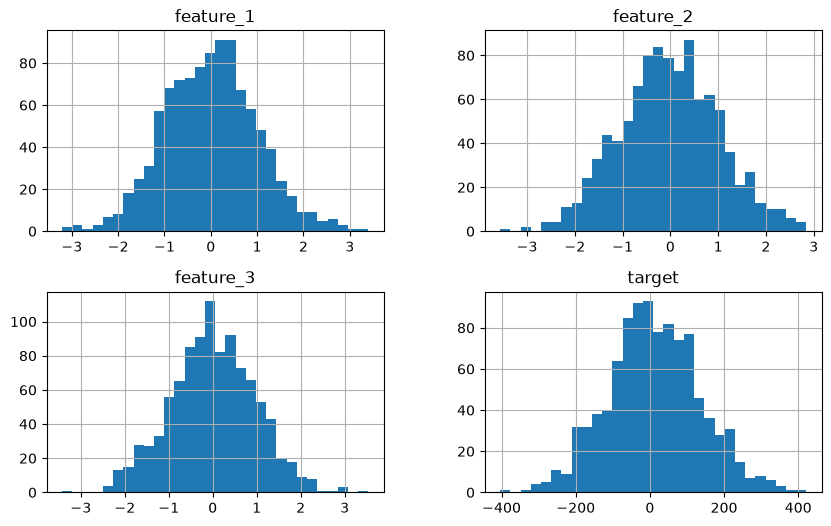

In [58]:
df.hist(bins=30, figsize=(10, 6))

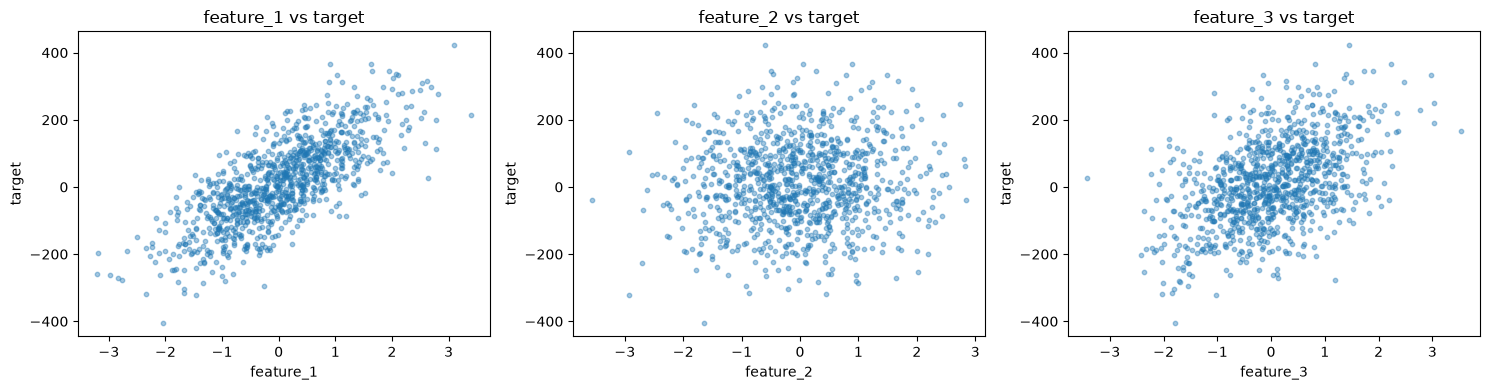

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, feature_names):
    ax.scatter(df[name], df['target'], alpha=0.4, s=10)
    ax.set_xlabel(name)
    ax.set_ylabel('target')
    ax.set_title(f'{name} vs target')

plt.tight_layout()
plt.show()

## Fit Baseline Linear Regression

In [60]:
from sklearn.linear_model import LinearRegression

X_full = df[feature_names]
y_full = df['target']

model = LinearRegression()
model.fit(X_full, y_full)

print('Estimated Coefficients: ', model.coef_)
print('True Coefficients: ', coefficients)
print('Estimated Intercept: ', model.intercept_) # true 10
print('R2: ', model.score(X_full, y_full))

Estimated Coefficients:  [96.58182913  6.54273118 66.47338981]
True Coefficients:  [97.82865624  6.91454126 68.91852335]
Estimated Intercept:  10.26907857741846
R2:  0.8364492163353965


## Baseline fit: OLS on the full synthetic dataset

### Setup

- Data generated with `make_regression`: 1,000 rows, 3 features (all informative), `bias=10`, `noise=50`, `random_state=13`.
- Model: `LinearRegression` fitted once on the full dataset.
- No train/test split, because the goal is to measure the sampling uncertainty of the coefficients, not out-of-sample prediction accuracy.

### Results

| Parameter | Estimated | True | Gap (estimated minus true) |
|---|---|---|---|
| feature_1 | 96.58 | 97.83 | -1.25 |
| feature_2 | 6.54 | 6.91 | -0.37 |
| feature_3 | 66.47 | 68.92 | -2.45 |
| intercept | 10.27 | 10.00 | +0.27 |

R-squared of the baseline fit: 0.836.

### Interpretation

- The expected standard error of each coefficient is roughly noise divided by the square root of the sample size: 50 / sqrt(1000), which is about **1.6**.
- All gaps are within about 1.5 standard errors of the truth (feature_1: 0.8, feature_2: 0.2, feature_3: 1.5, intercept: 0.2), so this sample gives estimates close to the true values.
- The gaps here are a single draw of estimation error. The bootstrap is meant to show how large that error typically is.
- feature_2 has a much smaller true coefficient (about 6.9) than the other two, so it is the weakest feature relative to the noise.

### Prediction to test with the bootstrap

- The bootstrap histograms will be centered on the estimates (feature_2 near 6.5), not exactly on the truth.
- The bootstrap standard deviation of each coefficient should come out near 1.6.
- The 95% percentile interval for feature_2 should be roughly 3 to 10, the closest to zero of the three, but probably still excluding zero.
- The intervals for feature_1 and feature_3 should be far from zero.

## Bootstrapping

In [61]:
n = len(df)
boot_coefs = []

for b in range(100):
    sample = df.sample(n=n, replace=True, random_state=b)
    m = LinearRegression().fit(sample[feature_names], sample['target'])
    boot_coefs.append(m.coef_)


boot_df = pd.DataFrame(boot_coefs, columns=feature_names)

## Bootstrap Results: Variability and Stability

In [66]:
summary = boot_df.agg(['mean', 'std']).T
summary['baseline_estimate'] = model.coef_
summary['true_coef'] = coefficients
summary['coef_of_variation'] = summary['std'] / summary['mean'].abs()

ci_lower = boot_df.quantile(0.025)
ci_upper = boot_df.quantile(0.975)
summary['ci_2.5%'] = ci_lower
summary['ci_97.5%'] = ci_upper
summary

,mean,std,baseline_estimate,true_coef,coef_of_variation,ci_2.5%,ci_97.5%
feature_1,96.243715,1.807307,96.581829,97.828656,0.018778,92.964144,99.763862
feature_2,6.458719,1.452682,6.542731,6.914541,0.224918,3.900460,9.301327
feature_3,66.505512,1.547700,66.473390,68.918523,0.023272,63.364073,69.308426


In [68]:
print(boot_df.quantile([0.025, 0.975]))
print((boot_df > 0).mean())

       feature_1  feature_2  feature_3
0.025  92.964144   3.900460  63.364073
0.975  99.763862   9.301327  69.308426
feature_1    1.0
feature_2    1.0
feature_3    1.0
dtype: float64


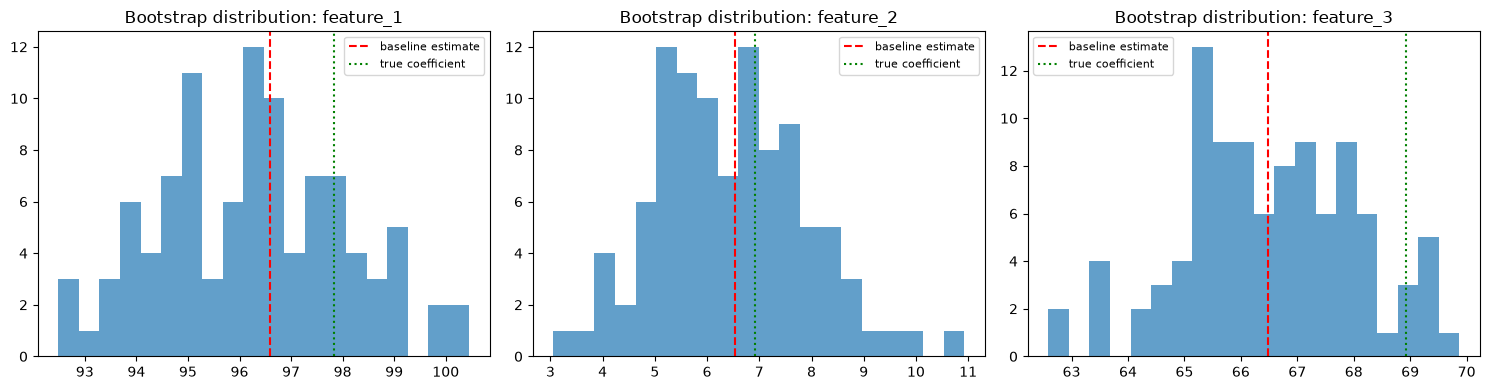

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, feature_names):
    ax.hist(boot_df[name], bins=20, alpha=0.7)
    ax.axvline(model.coef_[feature_names.index(name)], color='red', linestyle='--', label='baseline estimate')
    ax.axvline(coefficients[feature_names.index(name)], color='green', linestyle=':', label='true coefficient')
    ax.set_title(f'Bootstrap distribution: {name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### How stable are your estimates across bootstrapped samples?

The bootstrap standard deviations were 1.81, 1.45, and 1.55 for feature 1, 2, and 3, so in raw units the estimates moved by nearly the same amount for all three. However, relative to the size of each coefficient, feature_2 was the least stable. When comparing the **Coefficient of Variation (CV)** for all three, then we can see that for feature 1 and 3 it is at around 2%, but for feature 2 it is at above 20%. This indicates that there is a bigger volatility for the bootstrap coefficient of feature 2. 

$$CV = \frac{\text{Standard deviation}}{|\text{Mean}|}$$
**Summary**: Feature 1 and 3 are very stable, Feature 2 is noticeably less stable.

### Are some features consistently important?

All the features are consistently important. None of the bootstrap coefficients produced a coefficient near zero or with a flipped sign. Feature 1 and 3 are dominant with larger coefficients (bootstrap average of around 96 and 66), while feature 2 has a smaller coefficient with an average of 6.5. As discussed in the previous question, feature 2 is the least precise relative to its own magnitude because its **CV** is at about 22%.

### What does this tell you about uncertainty in your model?

The bootstrap shows that the uncertainty in my coefficients is small in absolute terms: the standard deviations are between 1.45 and 1.8 for all three features.
This uncertainty comes from two sources: the noise level in the data (50) and the sample size (1000). Together they give an expected standard error of about 1.6, which matches the bootstrap results. Compared with the size of the coefficients, the uncertainty is small for feature 1 and feature 3 but large for feature 2. The standard error is similar for all three features, because it depends on the noise and sample size, not on the size of the coefficient. So the same standard error of about 1.5 is a tiny fraction of feature_1 (about 96) but more than a fifth of feature_2 (about 6.5).

 If the noise were higher or the sample size smaller, the spread of the bootstrap estimates would increase.